# JHRMBS public-data MVP walkthrough

この Notebook は、CLI で作成済みの immutable artifact を読み、データ品質、回号月次 CPR、
時系列・vintage OOS、将来 cashflow と WAL を検証します。取得・変換・学習ロジックは
`jhrmbs` package にあり、Notebook 内に複製しません。

単位は `_pct` が百分率、SMM/Factor は小数、金額は JPY です。モデル特徴量は原則1か月 lag です。

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from jhrmbs.artifacts import read_table
from jhrmbs.cashflow_service import create_issue_cashflow
from jhrmbs.config import load_config
from jhrmbs.forecast import fixed_psj_forecast, forecast_issue
from jhrmbs.models.training import resolve_run_directory
from jhrmbs.paths import DataPaths

WORKSPACE_ROOT = Path.cwd()
CONFIG_PATH = WORKSPACE_ROOT / "JHRMBS" / "config" / "default.yml"
config = load_config(CONFIG_PATH)
paths = DataPaths(config.data_root)
print(f"data root: {config.data_root}")

data root: /home/kazumasa/projects/_data/jhrmbs


## 1. Data contract and quality

panel の grain、必須値、Factor の範囲・単調性、reconciliation を確認します。critical finding が
あれば `build-dataset` 自体が失敗します。reconciliation は異なる減少概念の診断で、完全一致は
要求しません。

In [2]:
panel = read_table(paths.processed / "issue_month_panel.parquet")
issues = read_table(paths.processed / "issues.parquet")
features = read_table(paths.features / "model_features.parquet")
quality = json.loads((paths.processed / "data_quality_report.json").read_text(encoding="utf-8"))

coverage = pd.DataFrame({
    "metric": ["rows", "issues", "observed rows", "first month", "last observed month", "critical findings"],
    "value": [
        len(panel), panel["issue_id"].nunique(), int(panel["is_observed"].sum()),
        panel["payment_month"].min().date(),
        panel.loc[panel["is_observed"], "payment_month"].max().date(),
        quality["panel"]["critical_count"],
    ],
})
coverage

,metric,value
0,rows,92592
1,issues,226
2,observed rows,23326
3,first month,2008-11-01
4,last observed month,2026-07-01
5,critical findings,0


In [3]:
finding_columns = ["severity", "check", "failed_count", "failed_rate", "message"]
findings = pd.DataFrame(quality["panel"]["findings"])
findings[finding_columns] if not findings.empty else pd.DataFrame(columns=finding_columns)

,severity,check,failed_count,failed_rate,message


## 2. Observed prepayment panel

将来予定行を除き、公表 CPR の分布と vintage 差を確認します。これは borrower-level 分布ではなく、
回号プール月次の分布です。

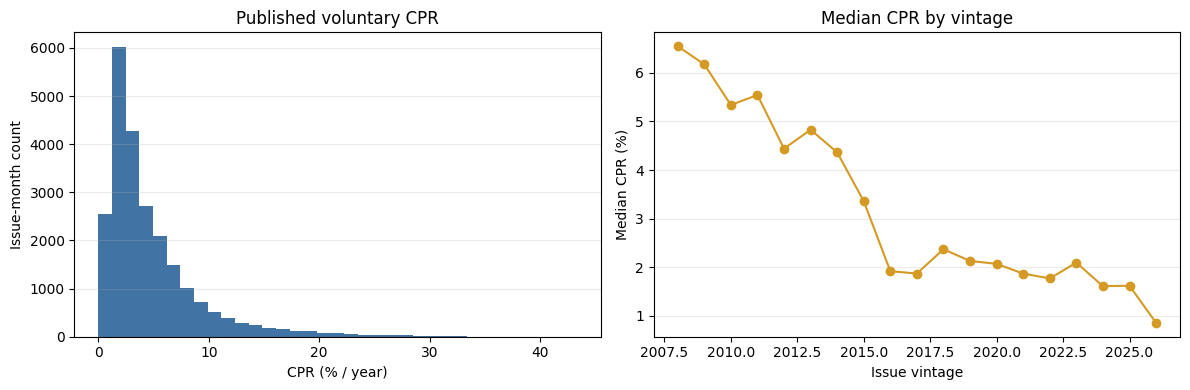

In [4]:
observed = panel[panel["voluntary_cpr_pct"].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(observed["voluntary_cpr_pct"], bins=35, color="#1f5a94", alpha=0.85)
axes[0].set(title="Published voluntary CPR", xlabel="CPR (% / year)", ylabel="Issue-month count")
vintage = observed.groupby("vintage_year")["voluntary_cpr_pct"].median()
axes[1].plot(vintage.index, vintage.values, marker="o", color="#d49a24")
axes[1].set(title="Median CPR by vintage", xlabel="Issue vintage", ylabel="Median CPR (%)")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout();

## 3. Out-of-sample comparison

固定 PSJ、seasoning、金利 proxy 付き、full model を、暦月 holdout と最新 vintage holdout で
比較します。主指標は前月残高加重 RMSE（CPR percentage point）です。

In [5]:
run_directory = resolve_run_directory(config)
metrics = read_table(run_directory / "metrics.parquet")
display_columns = [
    "split", "model", "train_rows", "test_rows", "rate_proxy_share",
    "weighted_rmse_cpr_pct", "weighted_mae_cpr_pct",
    "cashflow_cumulative_principal_mae_pct", "truncated_wal_mae_years",
]
metrics[display_columns].sort_values(["split", "weighted_rmse_cpr_pct"])

,split,model,train_rows,test_rows,rate_proxy_share,weighted_rmse_cpr_pct,weighted_mae_cpr_pct,cashflow_cumulative_principal_mae_pct,truncated_wal_mae_years
0,time,rate,20103,2478,1.0,1.325477,0.982570,1.200491,0.021762
1,time,full,20103,2478,1.0,1.363989,1.018773,1.256885,0.013776
2,time,fixed_psj,20103,2478,1.0,3.518973,3.251779,2.219167,0.015061
3,time,seasoning,20103,2478,1.0,3.746650,3.469382,2.339893,0.014433
4,vintage,seasoning,22428,153,1.0,1.148406,0.903082,0.270985,0.017655
5,vintage,fixed_psj,22428,153,1.0,1.451182,1.084945,1.005760,0.024475
6,vintage,rate,22428,153,1.0,1.490222,1.128215,1.052434,0.022465
7,vintage,full,22428,153,1.0,1.673968,1.298777,1.232585,0.018463


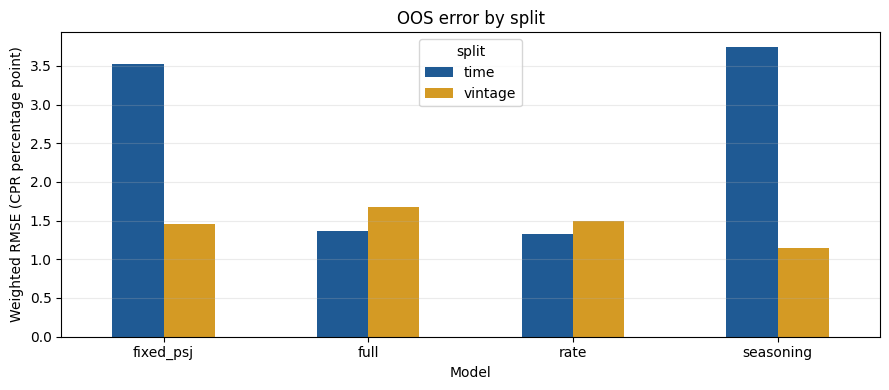

In [6]:
pivot = metrics.pivot(index="model", columns="split", values="weighted_rmse_cpr_pct")
pivot.plot.bar(figsize=(9, 4), color=["#1f5a94", "#d49a24"])
plt.ylabel("Weighted RMSE (CPR percentage point)")
plt.xlabel("Model")
plt.title("OOS error by split")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout();

## 4. Issue forecast and cashflow

直近実績より後に JHF 予定 Factor がある通常回号を自動選択します。モデル将来予測は直近の外部
状態を固定し、予定 Factor path だけを既知 schedule として使います。固定 PSJ と WAL を比較します。

In [7]:
observed_end = (
    panel[panel["is_observed"]].groupby("issue_id")["payment_month"].max().rename("observed_end")
)
candidates = panel.join(observed_end, on="issue_id")
candidates = candidates[
    (candidates["series_type"] == "monthly") &
    (candidates["payment_month"] > candidates["observed_end"])
]
future_counts = candidates.groupby("issue_id").size().sort_values(ascending=False)
issue_id = str(future_counts.index[0])
model_forecast = forecast_issue(config, issue_id, model_name="champion", save=False)
psj_forecast = fixed_psj_forecast(config, issue_id, terminal_cpr_pct=6.0)
selected_model_name = str(model_forecast["model_name"].iloc[0])
issue_id, selected_model_name, len(model_forecast), model_forecast["payment_month"].max().date()

('JHF-229', 'rate', 417, datetime.date(2061, 4, 1))

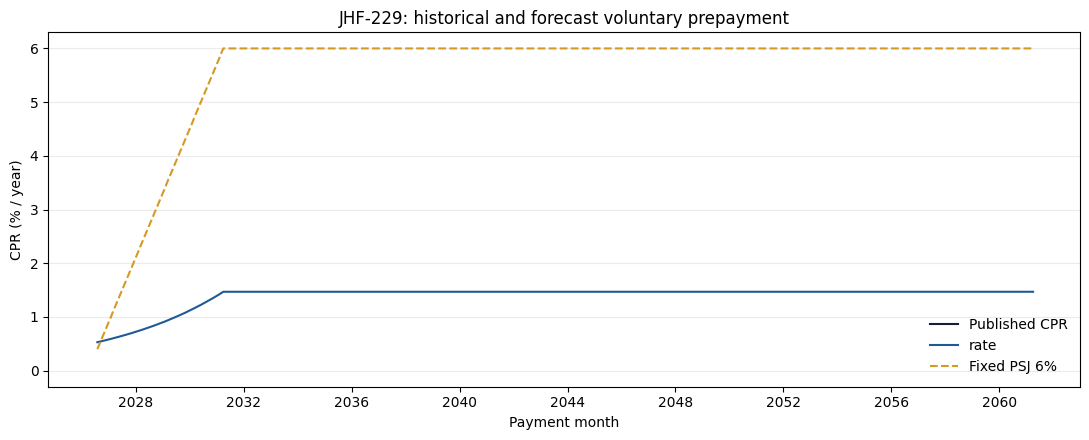

In [8]:
history = panel[(panel["issue_id"] == issue_id) & panel["voluntary_cpr_pct"].notna()].tail(48)
plt.figure(figsize=(11, 4.5))
plt.plot(history["payment_month"], history["voluntary_cpr_pct"], color="#172033", label="Published CPR")
plt.plot(model_forecast["payment_month"], model_forecast["predicted_cpr_pct"], color="#1f5a94", label=selected_model_name)
plt.plot(psj_forecast["payment_month"], psj_forecast["predicted_cpr_pct"], "--", color="#d49a24", label="Fixed PSJ 6%")
plt.ylabel("CPR (% / year)")
plt.xlabel("Payment month")
plt.title(f"{issue_id}: historical and forecast voluntary prepayment")
plt.grid(axis="y", alpha=0.25)
plt.legend(frameon=False)
plt.tight_layout();

In [9]:
model_cf, model_risk = create_issue_cashflow(config, issue_id, scenario="model", save=False)
psj_cf, psj_risk = create_issue_cashflow(config, issue_id, scenario="psj", save=False)
pd.DataFrame([
    {"scenario": selected_model_name, **model_risk},
    {"scenario": "fixed_psj_6pct", **psj_risk},
])[[
    "scenario", "wal_years", "dirty_price_per_100", "macaulay_duration_years",
    "effective_duration_years", "convexity", "annual_effective_yield_pct",
]]

,scenario,wal_years,dirty_price_per_100,macaulay_duration_years,effective_duration_years,convexity,annual_effective_yield_pct
0,model_rate,14.857105,116.326858,11.826109,11.594234,218.871977,2.0
1,psj_6pct,10.648260,112.221090,8.954550,8.778975,132.385268,2.0


## 5. Interpretation guardrails

- OOS 順位が split 間で逆転する場合、最良 model を確定せず regime / vintage 安定性を追加検証する。
- `rate_proxy_share` が高い期間の rate coefficient は借換効果と因果解釈しない。
- truncated WAL error と将来全期間 WAL は別指標である。
- clean-up call、回収月と支払月の lag、個別借換費用、OAS は MVP の外部仮定である。
